In [1]:
from pathlib import Path
import os

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns


from rdkit.Chem import Descriptors
import streamlit as st
from torch_geometric.data import Dataset
from torch_geometric.loader import DataLoader
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

from polynet.app.options.data import DataOptions
from polynet.app.options.state_keys import ExplainModelStateKeys, ProjectionPlotStateKeys
from polynet.app.services.explain_model import analyse_graph_embeddings, explain_model
from polynet.app.services.model_training import load_gnn_model
from polynet.app.utils import extract_number
from polynet.options.col_names import get_predicted_label_column_name, get_true_label_column_name
from polynet.options.enums import (
    DataSets,
    DimensionalityReduction,
    ExplainAlgorithms,
    ImportanceNormalisationMethods,
    ProblemTypes,
    Results,
)

from crystals_experiment.crystal_graph import crystal_graph_dataset

C:\Users\ezxac5\AppData\Local\anaconda3\envs\PoeHouse\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
save_name = "Wright-AL3_LOOCV_PCA_v2"
save = True

In [3]:
# Set save directory
results_dir = r"Cluster_Analysis"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

In [4]:
model_name = "TransformerConvGNN_1.pt"
model_dir = "C:\\Users\\ezxac5\\Documents\\GitHub\\PolyNet\\crystals_experiment\\results\\models"

In [5]:
device="cpu"
path = os.path.join(model_dir, model_name)
model = torch.load(path, weights_only=False, map_location=torch.device('cpu'))

In [6]:
data_options = DataOptions

In [7]:
# get the number of the iteration of the model
iteration = extract_number(model_name)

In [8]:
# Load training/validation/test data
general_dir = Path("crystals_experiment")

targets = pd.read_csv(general_dir / 'data/id_prop.csv', header=None)

dataset = crystal_graph_dataset(
    root= general_dir / "data",
    max_d=3.5,
    step=0.5,
    vor_cut_off=3.5,
    targets=targets
)

In [9]:
for i in enumerate(dataset):
    print(i)

(0, Data(x=[88, 17], edge_index=[2, 928], edge_attr=[928, 8], y=[1], idx='c1', coords=[88, 3], weight_monomer=[88]))
(1, Data(x=[88, 17], edge_index=[2, 928], edge_attr=[928, 8], y=[1], idx='c10', coords=[88, 3], weight_monomer=[88]))
(2, Data(x=[88, 17], edge_index=[2, 928], edge_attr=[928, 8], y=[1], idx='c11', coords=[88, 3], weight_monomer=[88]))
(3, Data(x=[88, 17], edge_index=[2, 928], edge_attr=[928, 8], y=[1], idx='c12', coords=[88, 3], weight_monomer=[88]))
(4, Data(x=[88, 17], edge_index=[2, 928], edge_attr=[928, 8], y=[1], idx='c13', coords=[88, 3], weight_monomer=[88]))
(5, Data(x=[88, 17], edge_index=[2, 928], edge_attr=[928, 8], y=[1], idx='c14', coords=[88, 3], weight_monomer=[88]))
(6, Data(x=[88, 17], edge_index=[2, 928], edge_attr=[928, 8], y=[1], idx='c15', coords=[88, 3], weight_monomer=[88]))
(7, Data(x=[88, 17], edge_index=[2, 928], edge_attr=[928, 8], y=[1], idx='c16', coords=[88, 3], weight_monomer=[88]))
(8, Data(x=[88, 17], edge_index=[2, 928], edge_attr=[928,

In [10]:
# Load tabular features (for PCA feature vectors)
tabular_data_file = r"C:\Users\ezxac5\OneDrive - The University of Nottingham\Tasks\papers\Paper_3\Eduardo\PolyNet_Wright_et_al_LOOCV\Wright_et_al_PolyNet_comps_PCA.csv"

In [11]:
# Load tabular features (for PCA vectors)
tabular_data = pd.read_csv(tabular_data_file)
tabular_data = tabular_data.loc[0:66] # Loading Wright et al data
tabular_data.reset_index(inplace=True, drop=True) # Reset data indices

# Create array to store composition names of each datapoint and array to store relevant features and target (for plots)
tabular_data_rel = tabular_data[['Comp', 'RA', 'RB', 'MA', 'MB', 'Entropy_conf', 'TC', 'Source']]

# Define features and target variable
tabular_data_features = tabular_data[['RA', 'RB', 'MA', 'MB', 'Entropy_conf']]

In [12]:
tabular_data.describe()

,La,Nd,Sm,Gd,Eu,Tm,Yb,Y,Dy,Ho,...,Ce.1,Ti,RA,RB,MA,MB,Entropy_conf,RA/RB,a2,TC
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.00000,67.000000,67.000000,67.000000,67.000000,...,67.0,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000
mean,0.130265,0.081959,0.160369,0.138096,0.124773,0.01150,0.015786,0.018015,0.034331,0.019464,...,0.0,0.058458,1.090776,0.711300,147.420152,96.912859,1.166848,1.534154,10.572739,1.938279
std,0.262666,0.192839,0.260025,0.220463,0.220210,0.05574,0.063422,0.067942,0.102617,0.076719,...,0.0,0.153532,0.029352,0.019175,7.103830,14.567329,0.681066,0.044406,0.093493,0.196832
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,1.045750,0.630417,123.013105,68.268917,0.171259,1.480556,10.296672,1.360000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,1.067722,0.715000,143.119232,91.224000,0.749940,1.498611,10.548402,1.870344
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,1.081429,0.720000,149.408402,91.224000,1.122773,1.528056,10.574281,1.972689
75%,0.121429,0.000000,0.267857,0.256579,0.250000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,1.110200,0.720000,153.191333,91.224000,1.520834,1.563889,10.635085,2.060496
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.36000,0.307692,0.391304,0.500000,0.450000,...,0.0,0.750000,1.160000,0.720000,158.153500,134.857000,2.939007,1.690945,10.728332,2.290000


In [13]:
# Normalize features
#Normalize using MinMaxScaler
tabular_data_features_a = np.array(tabular_data_features)

min_value = np.min(tabular_data_features_a, axis=0)
max_value = np.max(tabular_data_features_a, axis=0)

scaler = MinMaxScaler()

scaler.fit([min_value, max_value])

tabular_data_features_a = scaler.transform(tabular_data_features_a)

# Normalize using standard scaler

scaler2 = StandardScaler()

scaler2.fit(tabular_data_features)

tabular_data_features_ss = scaler2.transform(tabular_data_features)

In [14]:
print(tabular_data_features)

          RA        RB          MA          MB  Entropy_conf
0   1.079000  0.720000  150.360000   91.224000      0.171291
1   1.066000  0.720000  153.284923   91.224000      0.889716
2   1.067444  0.720000  153.240000   91.224000      0.942823
3   1.077571  0.720000  150.956857   91.224000      1.122773
4   1.068842  0.720000  154.909334   91.224000      1.131814
..       ...       ...         ...         ...           ...
62  1.045750  0.660000  158.153500   91.362000      2.376727
63  1.055500  0.662500  156.030000   69.545500      1.312607
64  1.111400  0.720000  145.117494   91.224000      1.634384
65  1.081429  0.715000  146.249303  134.857000      2.570402
66  1.081429  0.706667  146.249303  129.474667      2.939007

[67 rows x 5 columns]


In [15]:
pred_path = r'C:\Users\ezxac5\Documents\GitHub\PolyNet\crystals_experiment\results'
pred_file = os.path.join(pred_path, 'predictions.csv')

In [16]:
preds = pd.read_csv(pred_file)

In [17]:
preds.describe()

,Unnamed: 0,Bootstrap Iteration,True target,GCN Predicted target,GraphSAGE Predicted target,TransformerConvGNN Predicted target,GAT Predicted target,MPNN Predicted target,CGGNN Predicted target
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,14.500000,3.000000,1.981340,1.871503,1.867797,1.932339,1.922240,1.967024,1.938885
std,8.684438,1.418951,0.312987,0.326203,0.332473,0.312602,0.302614,0.292989,0.317118
min,0.000000,1.000000,1.360000,1.242565,0.887338,1.234504,1.211018,1.347398,1.262743
25%,7.000000,2.000000,1.710000,1.560142,1.615683,1.658221,1.672336,1.735917,1.659480
50%,14.500000,3.000000,2.100000,1.961499,1.942987,2.058047,2.006002,2.077632,2.050724
75%,22.000000,4.000000,2.240000,2.164427,2.127104,2.194180,2.154854,2.208679,2.189123
max,29.000000,5.000000,2.290400,2.315485,2.569966,2.283917,2.423288,2.341418,2.360597


In [18]:
# get the name of the predicted col name for the model selected by the user
predicted_col_name = get_predicted_label_column_name(target_variable_name=data_options.target_variable_name, model_name=model._name)

In [19]:
# get the number of the iteration of the model
iteration = extract_number(model_name)
print(iteration)

1


In [20]:
# filter the predictions to get only the predictions of the corresponding iteration and the corresponding model
preds_projection = preds.loc[preds['Bootstrap Iteration'] == iteration, [Results.Set.value, 'CGGNN Predicted target']]

In [21]:
print(preds_projection)

           Set  CGGNN Predicted target
0        Train                2.159772
1        Train                2.015235
2        Train                2.176636
3        Train                1.656550
4        Train                1.380356
5        Train                1.646738
6        Train                1.735261
7        Train                1.327918
8        Train                1.358548
9        Train                1.905646
10       Train                1.919148
11       Train                1.964501
12       Train                2.292532
13       Train                2.290186
14       Train                2.107955
15       Train                2.217414
16       Train                2.191123
17       Train                2.290734
18       Train                2.291030
19       Train                1.608215
20       Train                1.773796
21       Train                1.445600
22       Train                2.297410
23       Train                2.283685
24  Validation           

In [22]:
def get_graph_embeddings(dataset, model) -> np.ndarray:
    """
    Get graph embeddings for the dataset using the provided model.

    Args:
        dataset (CustomPolymerGraph): The dataset containing graph data.
        model: The model used to generate embeddings.

    Returns:
        np.ndarray: An array of graph embeddings.
    """
    loader = DataLoader(dataset=dataset, batch_size=1, shuffle=False)
    embeddings = []
    idx = []

    for batch in loader:
        with torch.no_grad():
            embedding = model.get_graph_embedding(
                x=batch.x,
                edge_index=batch.edge_index,
                edge_attr=batch.edge_attr,
                batch_index=batch.batch,
                monomer_weight=batch.weight_monomer,
            )
            embeddings.append(embedding.cpu().numpy())
            idx.append(batch.idx)

    idx = np.array(idx).flatten().tolist()
    
    embeddings = pd.DataFrame(np.concatenate(embeddings, axis=0), index=idx)

    return embeddings


In [23]:
def analyse_graph_embeddings(
    model,
    dataset,
    labels: pd.Series,
    style_by: pd.Series,
    mols_to_plot: list,
    reduction_method: str,
    reduction_parameters: dict,
    colormap: str,
):

    embeddings = get_graph_embeddings(dataset, model)

    if reduction_method == DimensionalityReduction.tSNE:
        tsne = TSNE(n_components=2, **reduction_parameters)
        reduced = tsne.fit_transform(embeddings)

    elif reduction_method == DimensionalityReduction.PCA:
        pca = PCA(n_components=2, **reduction_parameters)
        reduced = pca.fit_transform(embeddings)

    reduced_embeddings = pd.DataFrame(reduced, index=embeddings.index, columns=["Dim1", "Dim2"])
    reduced_embeddings = reduced_embeddings.loc[mols_to_plot]
    reduced_embeddings = reduced_embeddings.to_numpy()

    labels = labels.loc[mols_to_plot]

    projection_fig = plot_projection_embeddings(
        reduced_embeddings, labels=labels, cmap=colormap, style=style_by
    )
    st.pyplot(projection_fig, use_container_width=True)

In [24]:
embeddings = get_graph_embeddings(dataset, model)

In [25]:
print(embeddings)

          0         1         2         3         4         5         6    \
c1   0.225524  0.086509  0.663869 -0.008503 -0.004432  0.280648  0.361080   
c10  0.246737  0.173700  0.934880  0.172501  0.012175  0.432751  0.179370   
c11  0.242802  0.154092  0.535211  0.438667 -0.007263  0.553964  0.069704   
c12  0.268685  0.076895  0.538952 -0.009807 -0.005443  0.254425  0.510049   
c13  0.267525  0.175461  0.515259  0.004661 -0.005642  0.294031  0.378509   
..        ...       ...       ...       ...       ...       ...       ...   
c66  0.243515  0.144943  0.678706 -0.008737 -0.005162  0.257231  0.481760   
c67  0.287571  0.220803  0.265205  0.666374 -0.006498  0.540799  0.252358   
c7   0.291781  0.107321  0.455602  0.024589 -0.005282  0.327595  0.281499   
c8   0.262160  0.090020  0.560307 -0.009110 -0.005239  0.263054  0.439418   
c9   0.260228  0.113451  0.808088  0.021546 -0.004641  0.348530  0.269203   

          7         8         9    ...       118       119       120  \
c1 

In [26]:
#analyse_graph_embeddings(model, dataset)

In [27]:
embeddings = embeddings.sort_index(key=lambda idx: idx.str.extract(r'(\d+)').astype(int)[0]) # Sort embeddings by CIF IDs

In [28]:
print(embeddings)

          0         1         2         3         4         5         6    \
c1   0.225524  0.086509  0.663869 -0.008503 -0.004432  0.280648  0.361080   
c2   0.258991  0.104094  0.592461 -0.007484 -0.004803  0.283558  0.328973   
c3   0.248725  0.127023  0.590129 -0.007742 -0.004867  0.273022  0.397232   
c4   0.252738  0.088856  0.627905 -0.007157 -0.005146  0.287301  0.290953   
c5   0.242905  0.297352  0.575270  0.595920 -0.007413  0.613047  0.138136   
..        ...       ...       ...       ...       ...       ...       ...   
c63  0.325587  0.579074 -0.017120  0.144667  0.635725 -0.002889  0.540981   
c64  0.324554  0.465411 -0.014484  0.082852  0.639278  0.009669  0.443368   
c65  0.257779  0.104228  0.672609  0.003952 -0.004848  0.282698  0.329779   
c66  0.243515  0.144943  0.678706 -0.008737 -0.005162  0.257231  0.481760   
c67  0.287571  0.220803  0.265205  0.666374 -0.006498  0.540799  0.252358   

          7         8         9    ...       118       119       120  \
c1 

In [29]:
# Normalize embeddings using MinMaxScaler

embeddings_a = np.array(embeddings)

min_value = np.min(embeddings_a, axis=0)
max_value = np.max(embeddings_a, axis=0)

scaler_em = MinMaxScaler()

embeddings_a = scaler_em.fit_transform(embeddings_a)
embeddings_a = pd.DataFrame(embeddings_a, columns=embeddings.columns)

# Normalize using StandardScaler

embeddings_ss = np.array(embeddings)

scaler_em2 = StandardScaler()

embeddings_ss = scaler_em2.fit_transform(embeddings_ss)
embeddings_ss = pd.DataFrame(embeddings_ss, columns=embeddings.columns)

In [30]:
print(embeddings_a)

         0         1         2         3         4         5         6    \
0   0.198071  0.021075  0.392046  0.000844  0.002985  0.309170  0.544826   
1   0.466279  0.056022  0.350936  0.001487  0.002803  0.312332  0.496735   
2   0.384009  0.101591  0.349594  0.001324  0.002771  0.300883  0.598976   
3   0.416171  0.025739  0.371341  0.001693  0.002635  0.316400  0.439786   
4   0.337365  0.440105  0.341039  0.382332  0.001522  0.670377  0.210892   
..       ...       ...       ...       ...       ...       ...       ...   
62  1.000000  1.000000  0.000000  0.097518  0.317107  0.001060  0.814288   
63  0.991721  0.774107  0.001518  0.058503  0.318851  0.014706  0.668081   
64  0.456570  0.056290  0.397077  0.008705  0.002781  0.311397  0.497942   
65  0.342253  0.137205  0.400587  0.000696  0.002626  0.283723  0.725585   
66  0.695328  0.287971  0.162535  0.426800  0.001971  0.591867  0.381978   

         7         8         9    ...       118       119       120       121  \
0   0.

In [31]:
# Calculate principal components using orginal embeddings and normalized sets (both minmax and standardscaler)
## Orginial
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(embeddings)

## MinMaxScaler

pca_mms = PCA(n_components=2, random_state=42)
reduced_mms = pca_mms.fit_transform(embeddings_a)

# StandardScaler

pca_ss = PCA(n_components=2, random_state=42)
reduced_ss = pca_ss.fit_transform(embeddings_ss)

In [32]:
print(embeddings.index)

Index(['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9', 'c10', 'c11',
       'c12', 'c13', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21',
       'c22', 'c23', 'c24', 'c25', 'c26', 'c27', 'c28', 'c29', 'c30', 'c31',
       'c32', 'c33', 'c34', 'c35', 'c36', 'c37', 'c38', 'c39', 'c40', 'c41',
       'c42', 'c43', 'c44', 'c45', 'c46', 'c47', 'c48', 'c49', 'c50', 'c51',
       'c52', 'c53', 'c54', 'c55', 'c56', 'c57', 'c58', 'c59', 'c60', 'c61',
       'c62', 'c63', 'c64', 'c65', 'c66', 'c67'],
      dtype='object')


In [33]:
print(embeddings_ss.index)

RangeIndex(start=0, stop=67, step=1)


In [34]:
tabular_data_features_a = pd.DataFrame(tabular_data_features_a, columns=tabular_data_features.columns)
print(tabular_data_features_a)

          RA        RB        MA        MB  Entropy_conf
0   0.291028  1.000000  0.778218  0.344733      0.000011
1   0.177243  1.000000  0.861454  0.344733      0.259582
2   0.189886  1.000000  0.860175  0.344733      0.278770
3   0.278525  1.000000  0.795203  0.344733      0.343786
4   0.202119  1.000000  0.907680  0.344733      0.347053
..       ...       ...       ...       ...           ...
62  0.000000  0.330233  1.000000  0.346805      0.796846
63  0.085339  0.358140  0.939571  0.019171      0.412374
64  0.574617  1.000000  0.629031  0.344733      0.528634
65  0.312285  0.944186  0.661239  1.000000      0.866821
66  0.312285  0.851163  0.661239  0.919170      1.000000

[67 rows x 5 columns]


In [35]:
# Create merged dataframe for plot
# Using original tabular data features for PCA vectors as they are not the same features use for the PCA

## Original embeddings
components_df = pd.DataFrame(data=reduced,\
                            columns=['0', '1'])



plot_df = pd.concat([pd.DataFrame(embeddings.index), tabular_data_rel['Comp'], tabular_data_rel['Source'], components_df, targets[1], tabular_data_features], axis=1)
plot_df.columns = ['Id', 'Comp', 'Source', '0', '1', 'Target TC', 'RA', 'RB', 'MA', 'MB', 'Entropy_conf']

## MinMaxScaler
components_df_mms = pd.DataFrame(data=reduced_mms,\
                            columns=['0', '1'])



plot_df_mms = pd.concat([pd.DataFrame(embeddings.index), tabular_data_rel['Comp'], tabular_data_rel['Source'], components_df_mms, targets[1], tabular_data_features], axis=1)
plot_df_mms.columns = ['Id', 'Comp', 'Source', '0', '1', 'Target TC', 'RA', 'RB', 'MA', 'MB', 'Entropy_conf']

## StandardScaler

components_df_ss = pd.DataFrame(data=reduced_ss,\
                            columns=['0', '1'])



plot_df_ss = pd.concat([pd.DataFrame(embeddings.index), tabular_data_rel['Comp'],tabular_data_rel['Source'], components_df_ss, targets[1], tabular_data_features], axis=1)
plot_df_ss.columns = ['Id', 'Comp', 'Source', '0', '1', 'Target TC', 'RA', 'RB', 'MA', 'MB', 'Entropy_conf']


In [36]:
# Calculate loadings from graph features

loadings = pca.components_.T*np.sqrt(pca.explained_variance_)
loadings_mms = pca_mms.components_.T*np.sqrt(pca_mms.explained_variance_)
loadings_ss = pca_ss.components_.T*np.sqrt(pca_ss.explained_variance_)

In [37]:
# Calculate correlation between tabular features and PC1 and PC2 
# (for generating vectors based on the simplified tabular features)

tabular_feature_names = tabular_data_features.columns
correlations = []

for col in tabular_feature_names:
    corr_pc1 = np.corrcoef(tabular_data_features[col], reduced[:, 0])[0, 1]
    corr_pc2 = np.corrcoef(tabular_data_features[col], reduced[:, 1])[0, 1]
    correlations.append([corr_pc1, corr_pc2])

corr_df = pd.DataFrame(correlations, columns=['PC1', 'PC2'], index=tabular_feature_names)

In [38]:
print(correlations)

[[0.12532557075461198, -0.5045959694999894], [0.25840566989328034, -0.9098058790486527], [-0.013117476853092228, 0.5055907324685146], [-0.2079614838796423, -0.055511269972869606], [-0.04082767606526799, 0.5268534333833016]]


In [39]:
print(corr_df)

                   PC1       PC2
RA            0.125326 -0.504596
RB            0.258406 -0.909806
MA           -0.013117  0.505591
MB           -0.207961 -0.055511
Entropy_conf -0.040828  0.526853


In [40]:
# Calculate scaling factor for arrow visibility

scaling_factor = np.max(reduced)*0.8

In [41]:
print(components_df)

           0         1
0   2.767169 -0.740325
1   2.496794 -0.692090
2   2.536614 -0.578794
3   2.506953 -0.829899
4  -2.920003 -1.358317
..       ...       ...
62 -0.796756  7.565781
63 -0.260015  6.715956
64  2.181722 -0.789728
65  2.446588 -0.480038
66 -2.524287 -0.638694

[67 rows x 2 columns]


In [42]:
print(plot_df)

     Id                                               Comp        Source  \
0    c1                                 *Sm2.00Zr2.00O7.00    Random_gen   
1    c2                     *Sm1.38Eu0.15Dy0.46Zr2.00O7.00    Random_gen   
2    c3                     *Sm1.33Gd0.44Dy0.22Zr2.00O7.00    Random_gen   
3    c4                     *Nd0.86Sm0.76Er0.38Zr2.00O7.00    Random_gen   
4    c5                     *La0.53Gd0.53Dy0.95Zr2.00O7.00    Random_gen   
..  ...                                                ...           ...   
62  c63        (Sm1/4Gd1/4Eu1/4Yb1/4)2(Zr1/4Hf1/4Ti1/2)2O7  Wright_et_al   
63  c64                       (Sm3/4Yb1/4)2(Zr1/2Ti1/2)2O7  Wright_et_al   
64  c65                  (La1/5Nd1/5Sm1/5Eu1/5Ce1/5)2Zr2O7  Wright_et_al   
65  c66  (La1/7Nd1/7Sm1/7Gd1/7Eu1/7Pr1/7Ce1/7)2(Zr1/2Hf...  Wright_et_al   
66  c67  (La1/7Nd1/7Sm1/7Gd1/7Eu1/7Pr1/7Ce1/7)2(Zr1/3Hf...  Wright_et_al   

           0         1  Target TC        RA        RB          MA          MB  \
0   2.

In [43]:
import plotly.io as pio
pio.templates.default = "plotly"

In [44]:
# Separate data in df by TC grouping (low, medium, medium-high and high)

TC_group = []

for i, j in plot_df.iterrows():
    if j['Target TC']<1.6:
        TC_group.append('low')
    elif j['Target TC']>=1.6 and j['Target TC']<1.8:
        TC_group.append('med')
    elif j['Target TC']>=1.8 and j['Target TC']<2:
        TC_group.append('med-hi')
    else:
        TC_group.append('high')

TC_group = pd.DataFrame({'TC Group': TC_group})

In [45]:
plot_df = plot_df.join(TC_group)
plot_df_mms = plot_df_mms.join(TC_group)
plot_df_ss = plot_df_ss.join(TC_group)

In [46]:
print(plot_df)

     Id                                               Comp        Source  \
0    c1                                 *Sm2.00Zr2.00O7.00    Random_gen   
1    c2                     *Sm1.38Eu0.15Dy0.46Zr2.00O7.00    Random_gen   
2    c3                     *Sm1.33Gd0.44Dy0.22Zr2.00O7.00    Random_gen   
3    c4                     *Nd0.86Sm0.76Er0.38Zr2.00O7.00    Random_gen   
4    c5                     *La0.53Gd0.53Dy0.95Zr2.00O7.00    Random_gen   
..  ...                                                ...           ...   
62  c63        (Sm1/4Gd1/4Eu1/4Yb1/4)2(Zr1/4Hf1/4Ti1/2)2O7  Wright_et_al   
63  c64                       (Sm3/4Yb1/4)2(Zr1/2Ti1/2)2O7  Wright_et_al   
64  c65                  (La1/5Nd1/5Sm1/5Eu1/5Ce1/5)2Zr2O7  Wright_et_al   
65  c66  (La1/7Nd1/7Sm1/7Gd1/7Eu1/7Pr1/7Ce1/7)2(Zr1/2Hf...  Wright_et_al   
66  c67  (La1/7Nd1/7Sm1/7Gd1/7Eu1/7Pr1/7Ce1/7)2(Zr1/3Hf...  Wright_et_al   

           0         1  Target TC        RA        RB          MA          MB  \
0   2.

In [47]:
# # Generate PCA plot
# fig = px.scatter(plot_df_ss, x='0', y='1', color='RA', symbol='TC Group', 
#                  hover_name='Comp', hover_data=['RA', 'RB', 'MA', 'MB', 'Entropy_conf', 'Target TC'], 
#                  template='plotly_white', category_orders={"TC Group": ["low", "med", "med-hi", "high"]})

# # for feature, corr_val in corr_df.iterrows():
# #     fig.add_annotation(
# #         ax=0, ay=0,
# #         axref="x", ayref="y",
# #         x=corr_val['PC1']*scaling_factor,
# #         y=corr_val['PC2']*scaling_factor,
# #         showarrow=True,
# #         arrowsize=2,
# #         arrowhead=2,
# #         xanchor="right",
# #         yanchor="top"
# #     )
# #     fig.add_annotation(
# #         x=corr_val['PC1']*scaling_factor,
# #         y=corr_val['PC2']*scaling_factor,
# #         ax=0, ay=0,
# #         xanchor="center",
# #         yanchor="bottom",
# #         text=feature,
# #         yshift=5
# #     )

# fig.update_layout(
#     coloraxis=dict(
#         cmin=plot_df['RA'].min(),
#         cmax=plot_df['RA'].max()
#     )
# )

# fig.update_traces(marker=dict(size=10))

# fig.update_layout(
#     width=800, height=600
# )

# fig.update_layout(legend=dict(
#     orientation='h',
#     yanchor="top",
#     y=1.08,
#     xanchor="left",
#     x=0.01
# ))

# fig.show()
# #fig.write_html(results_dir + '\\' + f"{model_name[0:-3]}_PCA_ss-RA_PolyNet_Wright-AL3_LOOCV.html")

In [48]:
def pca_plot_cont(plot_df, feature, model_name, save_name="PCA", save=True):

    '''
    Plot PCA of graph embeddings. Markers are color coded based on selected tabular feature. Marker shape is based on low, 
    medium, medium-high and high thermal condcutivity.

    plot_df: Dataframe containing embeddings and other relevant info for the plot.
    feature: Selected tabular feature that will be represented via a heat map on the markers themselves.
    model_name: Name of model from which the embeddings were extracted. For save file name.
    '''

    target_groups = plot_df['TC Group'].unique()
    sources = plot_df['Source'].unique()

    fig = go.Figure()
    
    for i, tg in enumerate(target_groups):
        for src in sources:
    
            subset = plot_df[
                (plot_df['TC Group'] == tg) &
                (plot_df['Source'] == src)
            ]
    
            if len(subset) == 0:
                continue
    
            sub_id = [i for i in subset['Id']] # For hover data
         
            temp_df = plot_df.loc[plot_df['Id'].isin(sub_id)] # For hover data

            legendrank = 0
            symbol = 'triangle'
            
            if tg =='low':
                legendrank = 1
                symbol = 'circle'
            elif tg == 'med':
                legendrank = 2
                symbol = 'diamond'
            elif tg == 'med-hi':
                legendrank = 3
                symbol = 'square'
            else:
                legendrank = 4
                symbol = 'x'
    
            fig.add_trace(go.Scatter(
                x=subset['0'],
                y=subset['1'],
                mode='markers',
                name=f"{tg} | {src}",
                customdata=temp_df[['Comp', 'RA', 'RB', 'MA', 'MB', 'Entropy_conf', 'Target TC']],
                hovertemplate=
                    "Comp: %{customdata[0]}<br>" +
                    "RA: %{customdata[1]}<br>" +
                    "RB: %{customdata[2]}<br>" +
                    "MA: %{customdata[3]}<br>" +
                    "MB: %{customdata[4]}<br>" +
                    "Entropy_conf: %{customdata[5]}<br>" +
                    "TC: %{customdata[6]}",
                marker=dict(
                    size=10,
                    symbol=symbol,
                    color=subset[feature],
                    colorscale='plasma',
                    cmin=plot_df[feature].min(),
                    cmax=plot_df[feature].max(),
                    line=dict(
                        width=2,
                        color='black' if src == sources[0] else 'gray'
                    ),
                    colorbar=dict(title=feature) if (i == 0 and src == sources[0]) else None
                ),
                showlegend=True,
                legendrank=legendrank
            ))
    
    fig.update_layout(
        width=800,
        height=600,
        legend=dict(orientation='h', y=1.2),
        template='plotly_white'
    )
    
    fig.update_xaxes(title='PC1 (GNN latent)')
    fig.update_yaxes(title='PC2 (GNN latent)')

    fig.show()

    if save==True:
        fig.write_html(results_dir + '\\' + f"{model_name[0:-3]}_{save_name}-{feature}_plot.html")

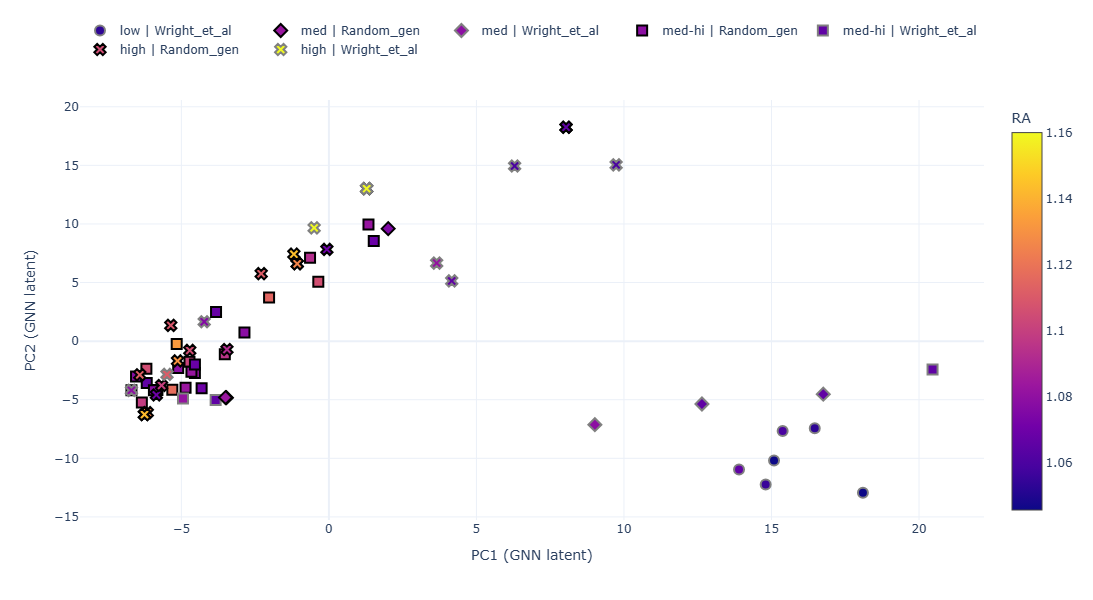

In [49]:
pca_plot_cont(plot_df_ss, 'RA', model_name, save_name=save_name+"_ss", save=save)

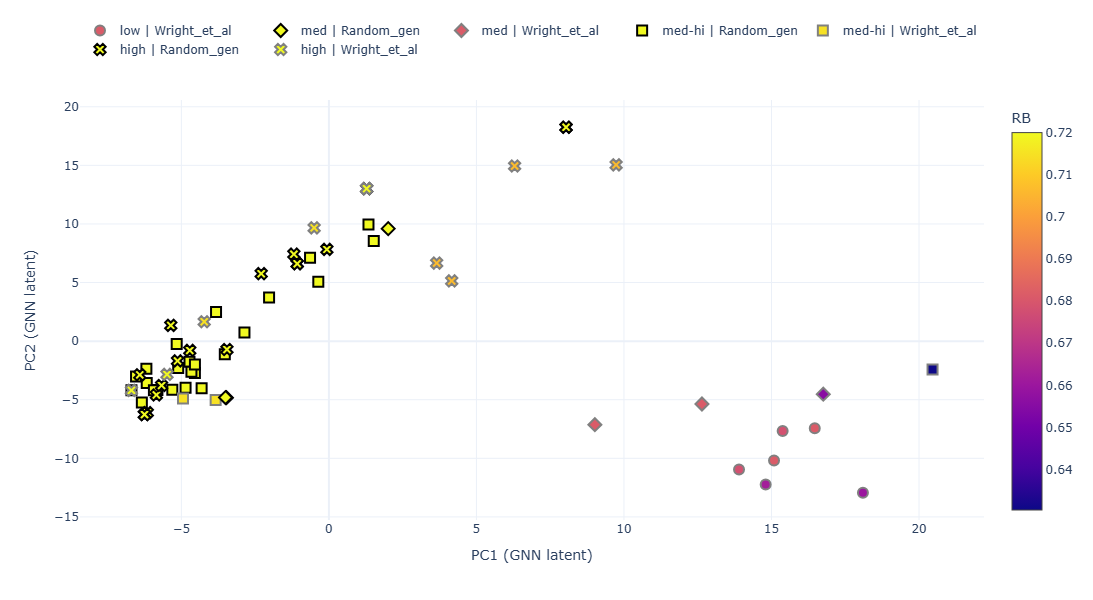

In [50]:
pca_plot_cont(plot_df_ss, 'RB', model_name, save_name=save_name+"_ss", save=save)

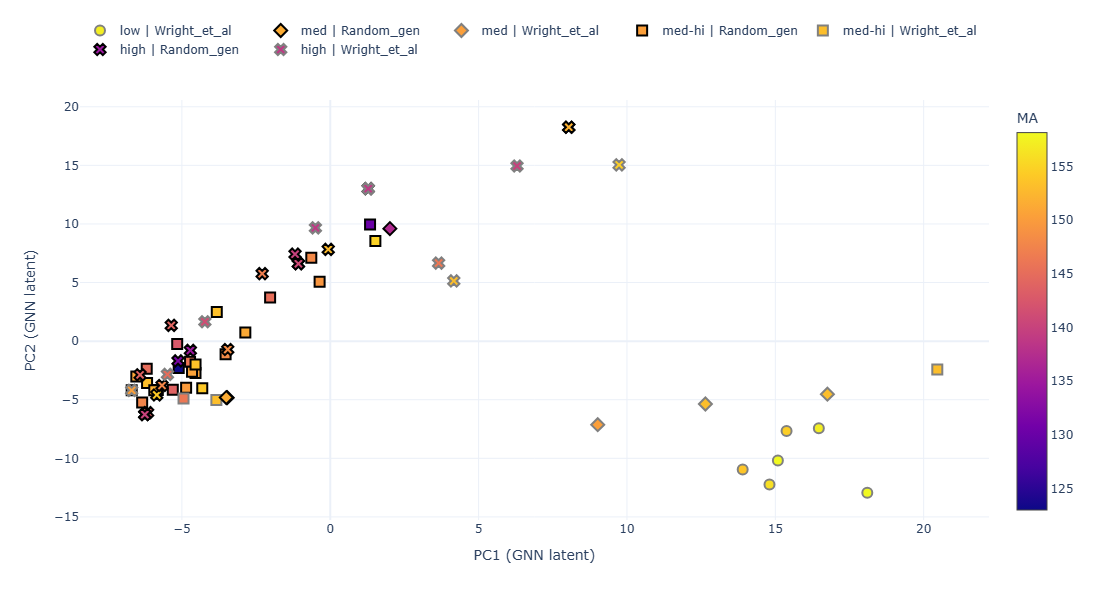

In [51]:
pca_plot_cont(plot_df_ss, 'MA', model_name, save_name=save_name+"_ss", save=save)

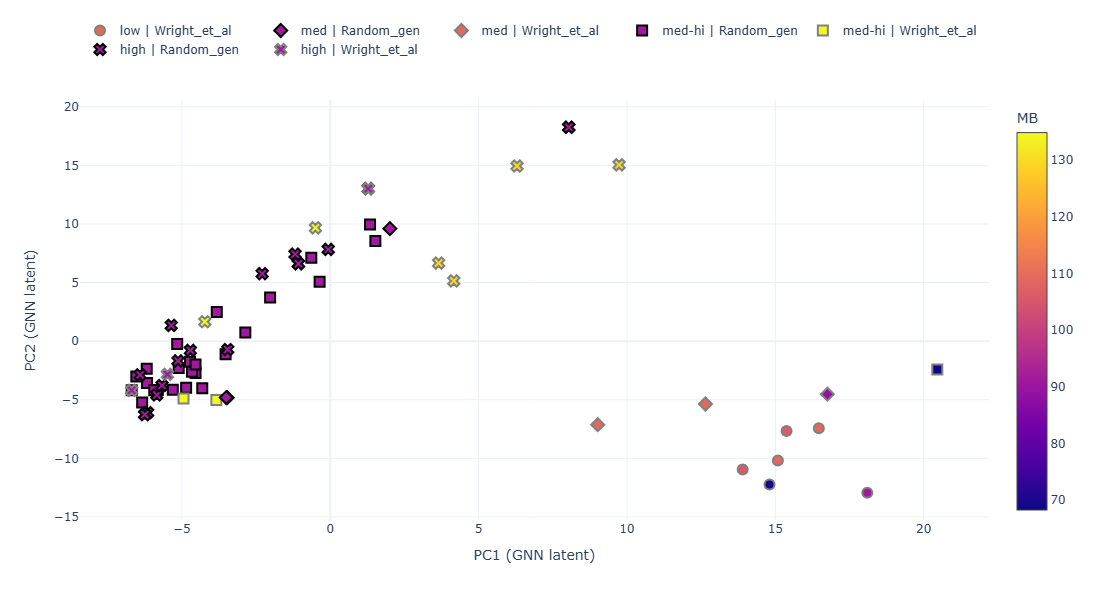

In [52]:
pca_plot_cont(plot_df_ss, 'MB', model_name, save_name=save_name+"_ss", save=save)

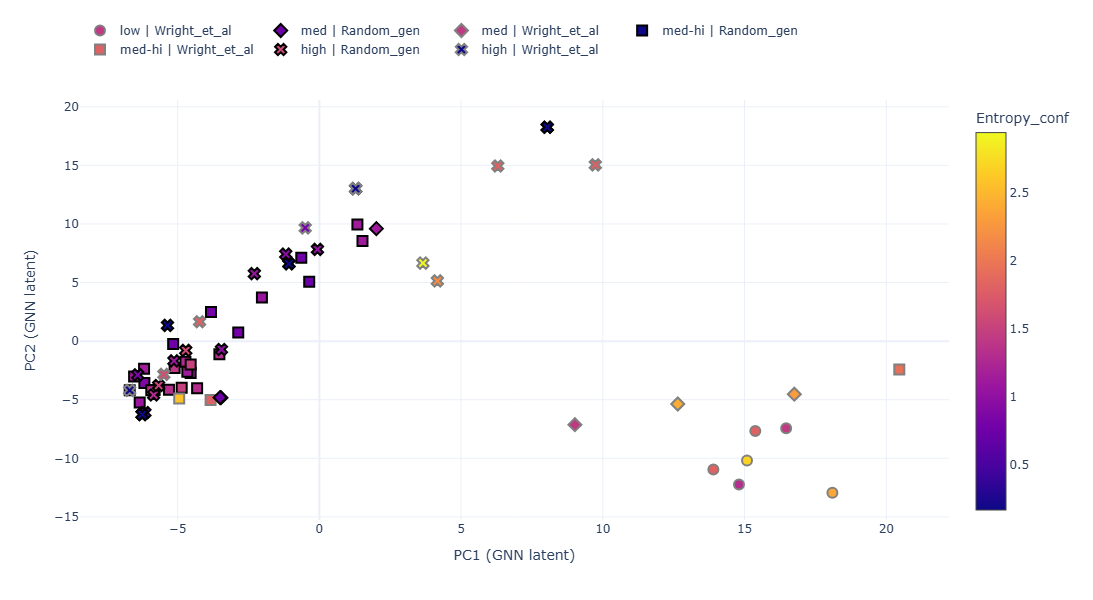

In [53]:
pca_plot_cont(plot_df_ss, 'Entropy_conf', model_name, save_name=save_name+"_ss", save=save)

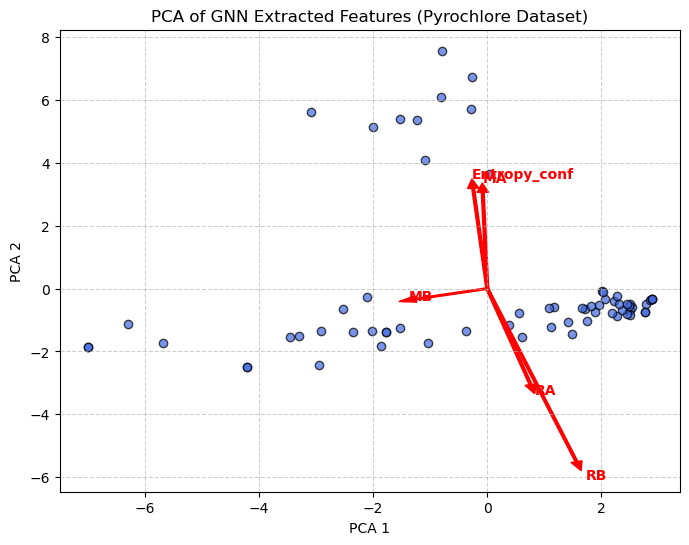

In [54]:
plt.figure(figsize=(8, 6))
plt.scatter(plot_df["0"], plot_df["1"], c='royalblue', edgecolors='k', alpha=0.7)
for i, row in corr_df.iterrows():
    plt.arrow(0, 0, row['PC1'] * scaling_factor, row['PC2'] * scaling_factor, 
              color='red', width=0.05, head_width=0.2)
    plt.text(row['PC1'] * scaling_factor * 1.1, row['PC2'] * scaling_factor * 1.1, 
             i, color='red', fontweight='bold')
plt.xlabel(f'PCA 1')
plt.ylabel(f'PCA 2')
plt.title('PCA of GNN Extracted Features (Pyrochlore Dataset)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [55]:
def plot_projection_embeddings(
    tsne_embeddings: np.ndarray, labels: list = None, cmap: str = "blues", style: list = None
) -> plt.Figure:
    """
    Plot projection of embeddings using seaborn (simplified version).

    Args:
        tsne_embeddings: 2D array of embeddings
        labels: Color mapping (optional)
        cmap: Colormap name (default: "blues")
        markers: List of marker styles for each point (optional)
    """
    fig, ax = plt.subplots(figsize=(10, 8), dpi=400)

    sns.scatterplot(
        x=tsne_embeddings[:, 0],
        y=tsne_embeddings[:, 1],
        hue=labels,
        style=style,
        palette=cmap,
        s=50,  # Adjust point size as needed
    )

    plt.title("Projection of Graph Embeddings", fontsize=25)
    plt.xlabel("Component 1", fontsize=22)
    plt.ylabel("Component 2", fontsize=22)
    plt.grid()

    # norm = Normalize(vmin=min(labels), vmax=max(labels))
    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    # sm.set_array([])
    # fig.colorbar(sm, ax=ax, label="Value")  # Explicitly pass `ax`
    # plt.gca().get_legend().remove()

    return fig

In [56]:
print(plot_df['Target TC'])

0     1.997615
1     1.899779
2     1.853862
3     1.932498
4     1.827643
        ...   
62    1.360000
63    1.400000
64    2.060000
65    1.970000
66    2.020000
Name: Target TC, Length: 67, dtype: float64
